# SpaBound — Human lymph node D1: RNA + ADT

The A1 and D1 examples share the same graph and training configuration. Their preprocessing and cluster counts follow their respective source notebooks. This is a runnable workflow example, not a claim of exact paper-table reproduction.

Provide your own paired H5AD files; data and previously generated results are not included. Install the package and notebook dependencies as described in the repository README, including R/mclust for clustering. Run all cells in order from a fresh kernel. Data layout and configuration notes are in [examples/README.md](README.md).

## 1. Imports, seeds and paths

In [1]:
import os
import random
import sys
from pathlib import Path

# Locate the source checkout before importing SpaBound.
# Also support Jupyter launched from the parent workspace containing SpaBound/.
cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for parent in (cwd, *cwd.parents)
        for candidate in (parent, parent / 'SpaBound')
        if (candidate / 'pyproject.toml').is_file()
        and (candidate / 'spabound' / '__init__.py').is_file()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(
        'Start Jupyter in the SpaBound repository, its examples/ directory, '
        'or the parent workspace containing SpaBound/.'
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    adjusted_mutual_info_score, homogeneity_score,
)

from spabound.preprocessing import pca, lsi, clr_normalize_each_cell
from spabound.graph_v2 import construct_boundary_aware_graphs_v2
from spabound.trainer import SpaBound
from spabound.utils import clustering


def setup_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def configured_root(variable, default_folder):
    value = Path(os.environ.get(variable, default_folder)).expanduser()
    return value if value.is_absolute() else REPO_ROOT / value


DATA_ROOT = configured_root('SPABOUND_DATA_DIR', 'data')
OUTPUT_ROOT = configured_root('SPABOUND_OUTPUT_DIR', 'outputs')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PREPROCESS_SEED = 42
setup_seed(PREPROCESS_SEED)

d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\_metadata.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Configuration and paired inputs

`SPABOUND_DATA_DIR` selects a root containing the dataset subfolders; it defaults to `data/` in the repository. `SPABOUND_OUTPUT_DIR` defaults to `outputs/`. Relative environment-variable paths are resolved from the repository root.

The inputs must have raw counts in `X`, matching unique spot identifiers in the same order, and spatial coordinates in `obsm['spatial']`. Reference labels are optional and are used only for the metric/plot cells here. Cluster counts are explicit example settings. The trainer seed is 2022; preprocessing uses 42 and the mclust helper uses R seed 2020.

In [2]:
DATASET = 'hln_d1'
DATA_DIR = DATA_ROOT / DATASET
OUTPUT_DIR = OUTPUT_ROOT / DATASET
RNA_PATH = DATA_DIR / 'adata_RNA.h5ad'
MODALITY2_PATH = DATA_DIR / 'adata_ADT.h5ad'
REFERENCE_KEY = 'ground_truth'
N_CLUSTERS = 11

GRAPH_CONFIG = {
    'n_neighbors_spatial': 24,
    'sigma_spatial': None,
    'beta_spatial': 0.8,
    'spatial_candidates_k': 20,
    'n_neighbors_feature': 8,
    'beta_feature': 1.2,
    'verbose': True,
}

TRAINING_CONFIG = {
    'datatype': 'SPOTS',
    'random_seed': 2022,
    'learning_rate': 0.0005,
    'weight_decay': 0.001,
    'dim_output': 160,
    'z_dim': 128,
    'n_latent_shared': 32,
    'n_latent_private': 12,
    'mmvae_weight': 1.0,
    'reconstruction_weight': 1.0,
    'kl_weight': 0.02,
    'edge_preserving_weight': 0.0005,
    'use_appnp': True,
    'appnp_hidden': 160,
    'appnp_layers': 2,
    'appnp_alpha': 0.15,
    'appnp_residual': True,
    'appnp_dropout': 0.0,
    'use_boundary_aware_graph': True,
    'use_edge_preserving_loss': True,
    'edge_preserving_type': 'charbonnier',
    'epochs': 800,
}

In [5]:
for input_path in (RNA_PATH, MODALITY2_PATH):
    if not input_path.is_file():
        raise FileNotFoundError(
            f'Missing {input_path}. Supply the paired H5AD data; see examples/README.md.'
        )
rna_raw = sc.read_h5ad(RNA_PATH)
modality2_raw = sc.read_h5ad(MODALITY2_PATH)
rna_raw.var_names_make_unique()
modality2_raw.var_names_make_unique()
if not rna_raw.obs_names.is_unique or not modality2_raw.obs_names.is_unique:
    raise ValueError('Spot identifiers must be unique in both modalities.')
if not rna_raw.obs_names.equals(modality2_raw.obs_names):
    raise ValueError('The two H5AD files must contain the same spots in the same order.')
for adata, name in ((rna_raw, 'RNA'), (modality2_raw, 'second modality')):
    if 'spatial' not in adata.obsm:
        raise ValueError(f'{name} requires coordinates in obsm["spatial"].')
    if not np.isfinite(np.asarray(adata.obsm['spatial'])).all():
        raise ValueError(f'{name} spatial coordinates must be finite.')
print(f'Loaded {rna_raw.n_obs} paired spots; device: {DEVICE}')

Loaded 3359 paired spots; device: cuda


d:\anaconda3\envs\sedrenv\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
d:\anaconda3\envs\sedrenv\Lib\site-packages\anndata\_core\anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 3. Modality-specific preprocessing

In [6]:
# Reset from fresh-loaded objects so this cell can be rerun safely.
setup_seed(PREPROCESS_SEED)
adata_omics1 = rna_raw.copy()
adata_omics2 = modality2_raw.copy()

sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor='seurat_v3', n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)
adata_high = adata_omics1[:, adata_omics1.var['highly_variable']]

# The source uses ADT feature count minus one: 30 PCs for 31 markers.
n_components = adata_omics2.n_vars - 1
adata_omics1.obsm['feat'] = pca(adata_high, n_comps=n_components)
adata_omics2 = clr_normalize_each_cell(adata_omics2)
sc.pp.scale(adata_omics2)
adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=n_components)

## 4. Boundary-aware graph construction

In [7]:
setup_seed(PREPROCESS_SEED)
graphs = construct_boundary_aware_graphs_v2(
    adata_omics1, adata_omics2, **GRAPH_CONFIG
)
data = {'adata_omics1': adata_omics1, 'adata_omics2': adata_omics2}
for key in (
    'adj_spatial_omics1', 'adj_spatial_omics2',
    'adj_feature_omics1', 'adj_feature_omics2',
):
    data[key] = graphs[key]
data['edge_gradients'] = graphs.get('edge_gradients')

Boundary-Aware Graph Construction V2 (Continuous Gradient-Based)
  N cells: 3359
  Spatial graph: k=24, sigma=auto, beta=0.8
  Feature graph: candidates=20, k=8, beta=1.2

----------------------------------------------------------------------
Step 1: Compute Fused Features
----------------------------------------------------------------------
  Fused features: 30 + 30 = 60 dims

----------------------------------------------------------------------
Step 2: Spatial Graphs (Continuous Gradient Penalty)
----------------------------------------------------------------------

Omics 1 - Spatial graph:
   Adaptive sigma_spatial: 3.1623
  Spatial graph V2: 3359 nodes, 80616 directed edges (41545 undirected)
   sigma_spatial: 3.1623, beta: 0.8000
   Median gradient: 3.1115, 80th percentile: 1.5586, 90th percentile: 1.9277
   Edges above median gradient: 50.0%
   Edges above 80th percentile: 20.0%
   Edges above 90th percentile: 10.0%
   Mean weight before attenuation: 0.3994
   Mean weight afte

## 5. Train SpaBound

In [8]:
setup_seed(PREPROCESS_SEED)
trainer = SpaBound(data=data, device=DEVICE, **TRAINING_CONFIG)
output = trainer.train()

Converting adjacency matrices to dense tensors...
 Adjacency matrices converted to dense tensors
Edge-preserving loss enabled: charbonnier (weight=0.0005)
Initializing SpaBound with APPNP encoders...
  APPNP hidden dim: 160
  APPNP layers: 2
  APPNP alpha: 0.15
  APPNP residual: True
  APPNP dropout: 0.0
Using APPNP encoders for enhanced long-range dependency capture

Training SpaBound with 800 epochs...
Encoder type: APPNP
MMVAE latent dims: shared=32, private=12
Private reconstruction: False


  8%|▊         | 64/800 [00:00<00:09, 79.85it/s]

Epoch 50/800
  Recon Loss (omics1): 5.1077
  Recon Loss (omics2): 1.0347
  KL Loss: 0.1303
  KL Weight (annealed): 0.0098
  MMVAE Loss: 0.0013
  Edge-Preserving Loss: 16309.5840
  Total Loss: 14.2985


 14%|█▎        | 109/800 [00:01<00:08, 85.70it/s]

Epoch 100/800
  Recon Loss (omics1): 5.1106
  Recon Loss (omics2): 1.0341
  KL Loss: 0.1164
  KL Weight (annealed): 0.0198
  MMVAE Loss: 0.0023
  Edge-Preserving Loss: 16129.9111
  Total Loss: 14.2120


...

Epoch 700/800
  Recon Loss (omics1): 5.0998
  Recon Loss (omics2): 1.0301
  KL Loss: 1.6646
  KL Weight (annealed): 0.0200
  MMVAE Loss: 0.0333
  Edge-Preserving Loss: 13989.8730
  Total Loss: 13.1581


 95%|█████████▍| 758/800 [00:09<00:00, 81.78it/s]

Epoch 750/800
  Recon Loss (omics1): 5.1002
  Recon Loss (omics2): 1.0302
  KL Loss: 1.8768
  KL Weight (annealed): 0.0200
  MMVAE Loss: 0.0375
  Edge-Preserving Loss: 13826.8291
  Total Loss: 13.0813


100%|██████████| 800/800 [00:09<00:00, 82.36it/s]

Epoch 800/800
  Recon Loss (omics1): 5.1001
  Recon Loss (omics2): 1.0300
  KL Loss: 2.0989
  KL Weight (annealed): 0.0200
  MMVAE Loss: 0.0420
  Edge-Preserving Loss: 13677.4414
  Total Loss: 13.0109
Model training finished!



## 6. Cluster the shared representation

`output['SpaBound']` contains the row-normalized shared posterior-mean representation. Clustering applies PCA20 followed by mclust with the stated cluster count. Auxiliary private coordinates are not interpreted as validated modality-specific biological factors.

In [9]:
setup_seed(PREPROCESS_SEED)
result = adata_omics1.copy()
result.obsm['SpaBound'] = output['SpaBound']
clustering(
    result, key='SpaBound', add_key='SpaBound',
    n_clusters=N_CLUSTERS, method='mclust', use_pca=True, n_comps=20,
)
result.obs['SpaBound'] = result.obs['SpaBound'].astype('category')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


## 7. Evaluate and visualize

ARI, NMI, AMI and homogeneity do not require aligning cluster identifiers. Missing reference labels are excluded from metrics and the evaluated count is reported. Predictions are not relabeled against the reference.

In [10]:
metrics = {'n_spots': int(result.n_obs)}
if REFERENCE_KEY in result.obs:
    valid = result.obs[REFERENCE_KEY].notna() & result.obs['SpaBound'].notna()
    metrics['n_evaluated'] = int(valid.sum())
    if not valid.any():
        raise ValueError('No spots have both reference and predicted labels.')
    truth = result.obs.loc[valid, REFERENCE_KEY].astype(str)
    prediction = result.obs.loc[valid, 'SpaBound'].astype(str)
    metrics.update(
        ARI=adjusted_rand_score(truth, prediction),
        NMI=normalized_mutual_info_score(truth, prediction),
        AMI=adjusted_mutual_info_score(truth, prediction),
        homogeneity=homogeneity_score(truth, prediction),
    )
else:
    print(f'No {REFERENCE_KEY!r} column: skipping reference-label metrics.')
pd.Series(metrics, name=DATASET)

n_spots        3359.000000
n_evaluated    3359.000000
ARI               0.358286
NMI               0.382939
AMI               0.377474
homogeneity       0.400954
Name: hln_d1, dtype: float64

d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages

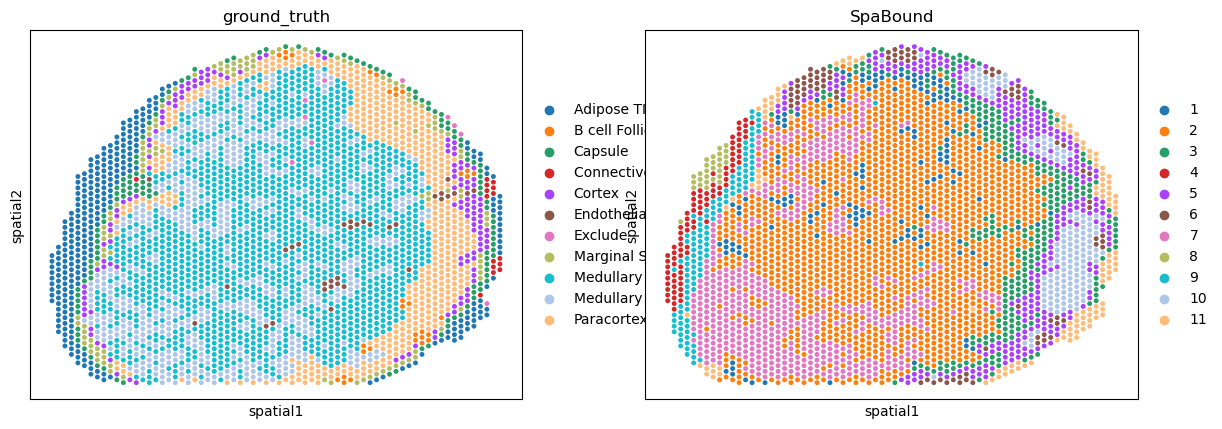

In [12]:
sc.pl.embedding(result, basis='spatial', color=colors, size=50)

## 8. Save outputs

Write a separate result H5AD, cluster labels, metrics and the settings used for this run. Input H5AD files are never overwritten. Rerunning this cell replaces the example's previous files in its output subfolder.

In [ ]:
import json

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Preserve the input RNA matrix; add results to a separate output file.
export = rna_raw.copy()
export.obs['SpaBound'] = result.obs['SpaBound'].astype(str).to_numpy()
export.obsm['SpaBound'] = result.obsm['SpaBound'].copy()
export.obsm['X_umap_SpaBound'] = result.obsm['X_umap'].copy()
export.write_h5ad(OUTPUT_DIR / 'spabound_result.h5ad')
result.obs[['SpaBound']].to_csv(OUTPUT_DIR / 'clusters.csv', index_label='spot_id')
pd.DataFrame([metrics]).to_csv(OUTPUT_DIR / 'metrics.csv', index=False)
configuration = {
    'dataset': DATASET,
    'preprocess_seed': PREPROCESS_SEED,
    'mclust_seed': 2020,
    'n_clusters': N_CLUSTERS,
    'graph': GRAPH_CONFIG,
    'training': TRAINING_CONFIG,
}
(OUTPUT_DIR / 'configuration.json').write_text(
    json.dumps(configuration, indent=2) + '\n', encoding='utf-8'
)
print(f'Results saved in {OUTPUT_DIR}')